# MP6: Proyecto de IA y Big Data — Tema 2: Proyecto de Regresión

**Predicción de ventas diarias para un e-commerce (diciembre 2010 – diciembre 2011)**

---

## Planteamiento del problema

El objetivo es predecir el **valor total de ventas por día** entre el **9 de noviembre de 2011** y el **9 de diciembre de 2011** (test set), utilizando los datos históricos del 1 de diciembre de 2010 al 8 de noviembre de 2011 para entrenamiento y validación.

| Conjunto | Período |
|----------|--------|
| **Entrenamiento + Validación** | 01/12/2010 → 08/11/2011 |
| **Test** | 09/11/2011 → 09/12/2011 |

---

## Estructura del notebook

1. [Carga del dataset](#1-carga)
2. [Análisis Exploratorio (EDA)](#2-eda)
   - 2.1 Entendimiento de los datos
   - 2.2 Valores faltantes, duplicados y erróneos
   - 2.3 Búsqueda de outliers
   - 2.4 Gráficos auxiliares
   - 2.5 Análisis temporal
   - 2.6 Análisis de cancelaciones
   - 2.7 Ventas diarias brutas (variable objetivo)
   - 2.8 Top clientes y top productos
3. Limpieza de datos *(próxima sección)*
4. Transformación de datos *(próxima sección)*
5. División train / validation / test *(próxima sección)*
6. Modelos de regresión *(próxima sección)*

## 0. Imports y configuración global

In [ ]:
import os

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Configuración visual global
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

# Rutas
RUTA_CSV      = 'contenidoCSV/data.csv'
RUTA_GRAFICOS = 'graficos/'
os.makedirs(RUTA_GRAFICOS, exist_ok=True)

print('Librerías cargadas correctamente.')

---
<a id="1-carga"></a>
## 1. Carga del dataset

El dataset es el fichero `data.csv` descargado de Kaggle. Contiene las transacciones de un e-commerce del Reino Unido entre el 1 de diciembre de 2010 y el 9 de diciembre de 2011.  
Se carga con `read_csv` de Pandas especificando `encoding='latin-1'` para evitar errores con caracteres especiales.

In [227]:
df = pd.read_csv(RUTA_CSV, encoding='latin-1')

print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
print('\nTipos de datos:')
print(df.dtypes)
print('\nPrimeras filas:')
df.head()

Filas: 541,909 | Columnas: 8

Tipos de datos:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object

Primeras filas:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


---
<a id="2-eda"></a>
## 2. Análisis Exploratorio de Datos (EDA)

Antes de limpiar o transformar nada, estudiamos a fondo el dataset para entender qué contiene cada columna, detectar anomalías y tomar decisiones informadas en la fase de limpieza.

### 2.1 Entendimiento de los datos

Exploramos dimensiones, tipos, valores únicos y estadísticas descriptivas. También identificamos transacciones con cantidades o precios negativos/cero, que en este dominio pueden corresponder a **devoluciones, regalos o ajustes contables**.

In [228]:
print('--- 2.1.1 Dimensiones y tipos de datos ---')
print(f'Filas: {df.shape[0]:,} | Columnas: {df.shape[1]}')
print('\nTipos de datos por columna:')
print(df.dtypes)

--- 2.1.1 Dimensiones y tipos de datos ---
Filas: 541,909 | Columnas: 8

Tipos de datos por columna:
InvoiceNo          str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
UnitPrice      float64
CustomerID     float64
Country            str
dtype: object


In [229]:
print('--- 2.1.2 Primeras 10 filas ---')
display(df.head(10))

print('\n--- 2.1.3 Últimas 10 filas ---')
display(df.tail(10))

--- 2.1.2 Primeras 10 filas ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,12/1/2010 8:26,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,12/1/2010 8:26,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,12/1/2010 8:28,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,12/1/2010 8:34,1.69,13047.0,United Kingdom



--- 2.1.3 Últimas 10 filas ---


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541899,581587,22726,ALARM CLOCK BAKELIKE GREEN,4,12/9/2011 12:50,3.75,12680.0,France
541900,581587,22730,ALARM CLOCK BAKELIKE IVORY,4,12/9/2011 12:50,3.75,12680.0,France
541901,581587,22367,CHILDRENS APRON SPACEBOY DESIGN,8,12/9/2011 12:50,1.95,12680.0,France
541902,581587,22629,SPACEBOY LUNCH BOX,12,12/9/2011 12:50,1.95,12680.0,France
541903,581587,23256,CHILDRENS CUTLERY SPACEBOY,4,12/9/2011 12:50,4.15,12680.0,France
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,12/9/2011 12:50,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,12/9/2011 12:50,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,12/9/2011 12:50,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,12/9/2011 12:50,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,12/9/2011 12:50,4.95,12680.0,France


In [230]:
print('--- 2.1.4 Valores únicos por columna ---')
for col in df.columns:
    print(f'  {col}: {df[col].nunique():,} valores únicos')

print('\n--- 2.1.5 Muestra de valores únicos (columnas categóricas) ---')
columnas_categoricas = ['InvoiceNo', 'StockCode', 'Description', 'Country']
for col in columnas_categoricas:
    muestra = df[col].dropna().unique()[:10]
    print(f'\n  {col} (primeros 10 únicos):')
    print(f'  {muestra}')

--- 2.1.4 Valores únicos por columna ---
  InvoiceNo: 25,900 valores únicos
  StockCode: 4,070 valores únicos
  Description: 4,223 valores únicos
  Quantity: 722 valores únicos
  InvoiceDate: 23,260 valores únicos
  UnitPrice: 1,630 valores únicos
  CustomerID: 4,372 valores únicos
  Country: 38 valores únicos

--- 2.1.5 Muestra de valores únicos (columnas categóricas) ---

  InvoiceNo (primeros 10 únicos):
  <StringArray>
['536365', '536366', '536367', '536368', '536369', '536370', '536371',
 '536372', '536373', '536374']
Length: 10, dtype: str

  StockCode (primeros 10 únicos):
  <StringArray>
['85123A',  '71053', '84406B', '84029G', '84029E',  '22752',  '21730',
  '22633',  '22632',  '84879']
Length: 10, dtype: str

  Description (primeros 10 únicos):
  <StringArray>
[ 'WHITE HANGING HEART T-LIGHT HOLDER',                 'WHITE METAL LANTERN',
      'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE',
      'RED WOOLLY HOTTIE WHITE HEART.',        'SET 7 BABUSHK

In [231]:
print('--- 2.1.6 Estadísticas descriptivas (columnas numéricas) ---')
df.describe()

--- 2.1.6 Estadísticas descriptivas (columnas numéricas) ---


,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [232]:
print('--- 2.1.7 Transacciones con Quantity <= 0 ---')
trans_qty_negativa = df[df['Quantity'] <= 0]
print(f'  Total filas con Quantity <= 0: {len(trans_qty_negativa):,}')
print(f'  % sobre total: {len(trans_qty_negativa) / len(df) * 100:.2f}%')
display(trans_qty_negativa[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head(10))

print('\n--- 2.1.8 Transacciones con UnitPrice <= 0 ---')
trans_price_negativa = df[df['UnitPrice'] <= 0]
print(f'  Total filas con UnitPrice <= 0: {len(trans_price_negativa):,}')
print(f'  % sobre total: {len(trans_price_negativa) / len(df) * 100:.2f}%')
display(trans_price_negativa[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head(10))

--- 2.1.7 Transacciones con Quantity <= 0 ---
  Total filas con Quantity <= 0: 10,624
  % sobre total: 1.96%


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
141,C536379,D,Discount,-1,27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,1.65
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,0.29
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,0.29
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,0.29
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,3.45
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,1.65
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,1.65
939,C536506,22960,JAM MAKING SET WITH JARS,-6,4.25



--- 2.1.8 Transacciones con UnitPrice <= 0 ---
  Total filas con UnitPrice <= 0: 2,517
  % sobre total: 0.46%


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
622,536414,22139,NaN,56,0.0
1970,536545,21134,NaN,1,0.0
1971,536546,22145,NaN,1,0.0
1972,536547,37509,NaN,1,0.0
1987,536549,85226A,NaN,1,0.0
1988,536550,85044,NaN,1,0.0
2024,536552,20950,NaN,1,0.0
2025,536553,37461,NaN,3,0.0
2026,536554,84670,NaN,23,0.0
2406,536589,21777,NaN,-10,0.0


### 2.2 Valores faltantes, duplicados y erróneos

Usamos `isnull`, `duplicated` y `value_counts` para cuantificar los problemas de calidad del dato:
- **CustomerID nulo**: transacciones anónimas (sin cliente registrado).
- **Description nula**: líneas de factura sin descripción de producto.
- **Filas duplicadas**: registros idénticos en todas sus columnas.
- **StockCodes no estándar**: códigos que no siguen el patrón `[0-9]{5}[A-Za-z]?` (p.ej. `POST`, `D`, `M`, `BANK CHARGES`).

In [233]:
print('--- 2.2.1 Valores faltantes (NaN) por columna ---')
nulos     = df.isnull().sum()
nulos_pct = nulos / len(df) * 100
resumen_nulos = pd.DataFrame({'Nulos': nulos, '% sobre total': nulos_pct.round(2)})
display(resumen_nulos[resumen_nulos['Nulos'] > 0])

--- 2.2.1 Valores faltantes (NaN) por columna ---


,Nulos,% sobre total
Description,1454,0.27
CustomerID,135080,24.93


In [234]:
print('--- 2.2.2 Filas sin CustomerID ---')
sin_cliente = df[df['CustomerID'].isnull()]
print(f'  Total: {len(sin_cliente):,} ({len(sin_cliente) / len(df) * 100:.2f}%)')
print('\n  Distribución por país (top 10):')
print(sin_cliente['Country'].value_counts().head(10))

--- 2.2.2 Filas sin CustomerID ---
  Total: 135,080 (24.93%)

  Distribución por país (top 10):
Country
United Kingdom    133600
EIRE                 711
Hong Kong            288
Unspecified          202
Switzerland          125
France                66
Israel                47
Portugal              39
Bahrain                2
Name: count, dtype: int64


In [235]:
print('--- 2.2.3 Filas sin Description ---')
sin_descripcion = df[df['Description'].isnull()]
print(f'  Total: {len(sin_descripcion):,} ({len(sin_descripcion) / len(df) * 100:.2f}%)')
display(sin_descripcion[['InvoiceNo', 'StockCode', 'Quantity', 'UnitPrice', 'CustomerID']].head(10))

print('\n--- 2.2.4 Filas sin CustomerID y sin Description simultáneamente ---')
sin_ambos = df[df['CustomerID'].isnull() & df['Description'].isnull()]
print(f'  Total: {len(sin_ambos):,}')

--- 2.2.3 Filas sin Description ---
  Total: 1,454 (0.27%)


,InvoiceNo,StockCode,Quantity,UnitPrice,CustomerID
622,536414,22139,56,0.0,NaN
1970,536545,21134,1,0.0,NaN
1971,536546,22145,1,0.0,NaN
1972,536547,37509,1,0.0,NaN
1987,536549,85226A,1,0.0,NaN
1988,536550,85044,1,0.0,NaN
2024,536552,20950,1,0.0,NaN
2025,536553,37461,3,0.0,NaN
2026,536554,84670,23,0.0,NaN
2406,536589,21777,-10,0.0,NaN



--- 2.2.4 Filas sin CustomerID y sin Description simultáneamente ---
  Total: 1,454


In [236]:
print('--- 2.2.5 Filas duplicadas (exactas) ---')
duplicados = df.duplicated()
print(f'  Total: {duplicados.sum():,} ({duplicados.sum() / len(df) * 100:.2f}%)')
display(df[duplicados].head(10))

--- 2.2.5 Filas duplicadas (exactas) ---
  Total: 5,268 (0.97%)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
587,536412,22273,FELTCRAFT DOLL MOLLY,1,12/1/2010 11:49,2.95,17920.0,United Kingdom
589,536412,22749,FELTCRAFT PRINCESS CHARLOTTE DOLL,1,12/1/2010 11:49,3.75,17920.0,United Kingdom
594,536412,22141,CHRISTMAS CRAFT TREE TOP ANGEL,1,12/1/2010 11:49,2.10,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
600,536412,22569,FELTCRAFT CUSHION BUTTERFLY,2,12/1/2010 11:49,3.75,17920.0,United Kingdom


In [237]:
print('--- 2.2.6 Formato de InvoiceDate (actualmente string) ---')
print('  Muestra de valores de InvoiceDate:')
print(df['InvoiceDate'].value_counts().head(10))
print(f'\n  Min: {df["InvoiceDate"].min()}')
print(f'  Max: {df["InvoiceDate"].max()}')

--- 2.2.6 Formato de InvoiceDate (actualmente string) ---
  Muestra de valores de InvoiceDate:
InvoiceDate
10/31/2011 14:41    1114
12/8/2011 9:28       749
12/9/2011 10:03      731
12/5/2011 17:24      721
6/29/2011 15:58      705
11/30/2011 15:13     687
12/8/2011 9:20       676
12/6/2010 16:57      675
12/5/2011 17:28      662
12/9/2010 14:09      652
Name: count, dtype: int64

  Min: 1/10/2011 10:04
  Max: 9/9/2011 9:52


In [238]:
print('--- 2.2.7 StockCodes no estándar (posibles errores) ---')
# Patrón estándar: 5 dígitos + letra opcional
stock_no_estandar = df[~df['StockCode'].str.match(r'^[0-9]{5}[A-Za-z]?$', na=False)]
print(f'  Total filas con StockCode no estándar: {len(stock_no_estandar):,}')
print('  Tipos de StockCodes no estándar (top 15):')
print(stock_no_estandar['StockCode'].value_counts().head(15))

--- 2.2.7 StockCodes no estándar (posibles errores) ---
  Total filas con StockCode no estándar: 3,385
  Tipos de StockCodes no estándar (top 15):
StockCode
POST            1256
DOT              710
M                571
15056BL          326
C2               144
D                 77
S                 63
15056bl           62
BANK CHARGES      37
AMAZONFEE         34
CRUK              16
DCGSSGIRL         13
DCGSSBOY          11
gift_0001_20      10
gift_0001_10       9
Name: count, dtype: int64


In [239]:
print('--- 2.2.8 Distribución de Country (value_counts) ---')
print(df['Country'].value_counts())

--- 2.2.8 Distribución de Country (value_counts) ---
Country
United Kingdom          495478
Germany                   9495
France                    8557
EIRE                      8196
Spain                     2533
Netherlands               2371
Belgium                   2069
Switzerland               2002
Portugal                  1519
Australia                 1259
Norway                    1086
Italy                      803
Channel Islands            758
Finland                    695
Cyprus                     622
Sweden                     462
Unspecified                446
Austria                    401
Denmark                    389
Japan                      358
Poland                     341
Israel                     297
USA                        291
Hong Kong                  288
Singapore                  229
Iceland                    182
Canada                     151
Greece                     146
Malta                      127
United Arab Emirates        68
European 

### 2.3 Búsqueda de outliers

Aplicamos el **método IQR** (rango intercuartílico) tanto a `Quantity` como a `UnitPrice` para identificar valores extremos que podrían distorsionar el modelo. Como regla general, esperamos que el **90–95 % de los datos queden dentro del rango normal**.

$$\text{Límite inferior} = Q1 - 1{,}5 \cdot IQR \qquad \text{Límite superior} = Q3 + 1{,}5 \cdot IQR$$

In [240]:
print('--- 2.3.1 Outliers en Quantity (método IQR) ---')
Q1_qty  = df['Quantity'].quantile(0.25)
Q3_qty  = df['Quantity'].quantile(0.75)
IQR_qty = Q3_qty - Q1_qty
lim_inf_qty = Q1_qty - 1.5 * IQR_qty
lim_sup_qty = Q3_qty + 1.5 * IQR_qty
outliers_qty = df[(df['Quantity'] < lim_inf_qty) | (df['Quantity'] > lim_sup_qty)]

print(f'  Q1={Q1_qty} | Q3={Q3_qty} | IQR={IQR_qty}')
print(f'  Límite inferior: {lim_inf_qty:.2f} | Límite superior: {lim_sup_qty:.2f}')
print(f'  Total outliers: {len(outliers_qty):,} ({len(outliers_qty) / len(df) * 100:.2f}%)')

print('\n  Top 5 mayores:')
display(df.nlargest(5, 'Quantity')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']])
print('\n  Top 5 menores:')
display(df.nsmallest(5, 'Quantity')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']])

--- 2.3.1 Outliers en Quantity (método IQR) ---
  Q1=1.0 | Q3=10.0 | IQR=9.0
  Límite inferior: -12.50 | Límite superior: 23.50
  Total outliers: 58,619 (10.82%)

  Top 5 mayores:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
540421,581483,23843,"PAPER CRAFT , LITTLE BIRDIE",80995,2.08
61619,541431,23166,MEDIUM CERAMIC TOP STORAGE JAR,74215,1.04
502122,578841,84826,ASSTD DESIGN 3D PAPER STICKERS,12540,0.00
74614,542504,37413,NaN,5568,0.00
421632,573008,84077,WORLD WAR 2 GLIDERS ASSTD DESIGNS,4800,0.21



  Top 5 menores:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
540422,C581484,23843,"PAPER CRAFT , LITTLE BIRDIE",-80995,2.08
61624,C541433,23166,MEDIUM CERAMIC TOP STORAGE JAR,-74215,1.04
225529,556690,23005,printing smudges/thrown away,-9600,0.00
225530,556691,23005,printing smudges/thrown away,-9600,0.00
4287,C536757,84347,ROTATING SILVER ANGELS T-LIGHT HLDR,-9360,0.03


In [241]:
print('--- 2.3.2 Outliers en UnitPrice (método IQR) ---')
Q1_price  = df['UnitPrice'].quantile(0.25)
Q3_price  = df['UnitPrice'].quantile(0.75)
IQR_price = Q3_price - Q1_price
lim_inf_price = Q1_price - 1.5 * IQR_price
lim_sup_price = Q3_price + 1.5 * IQR_price
outliers_price = df[(df['UnitPrice'] < lim_inf_price) | (df['UnitPrice'] > lim_sup_price)]

print(f'  Q1={Q1_price} | Q3={Q3_price} | IQR={IQR_price}')
print(f'  Límite inferior: {lim_inf_price:.2f} | Límite superior: {lim_sup_price:.2f}')
print(f'  Total outliers: {len(outliers_price):,} ({len(outliers_price) / len(df) * 100:.2f}%)')

print('\n  Top 5 precios más altos:')
display(df.nlargest(5, 'UnitPrice')[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']])

--- 2.3.2 Outliers en UnitPrice (método IQR) ---
  Q1=1.25 | Q3=4.13 | IQR=2.88
  Límite inferior: -3.07 | Límite superior: 8.45
  Total outliers: 39,627 (7.31%)

  Top 5 precios más altos:


,InvoiceNo,StockCode,Description,Quantity,UnitPrice
222681,C556445,M,Manual,-1,38970.00
524602,C580605,AMAZONFEE,AMAZON FEE,-1,17836.46
43702,C540117,AMAZONFEE,AMAZON FEE,-1,16888.02
43703,C540118,AMAZONFEE,AMAZON FEE,-1,16453.71
15016,C537630,AMAZONFEE,AMAZON FEE,-1,13541.33


In [242]:
print('--- 2.3.3 StockCodes menos frecuentes (outliers categóricos) ---')
stock_freq  = df['StockCode'].value_counts()
stock_raros = stock_freq[stock_freq <= 3]
print(f'  StockCodes con ≤3 apariciones: {len(stock_raros):,}')
print(stock_raros.head(10))

print('\n--- 2.3.4 Descriptions menos frecuentes (outliers categóricos) ---')
desc_freq  = df['Description'].value_counts()
desc_raras = desc_freq[desc_freq <= 3]
print(f'  Descriptions con ≤3 apariciones: {len(desc_raras):,}')
print(desc_raras.head(10))

--- 2.3.3 StockCodes menos frecuentes (outliers categóricos) ---
  StockCodes con ≤3 apariciones: 459
StockCode
20820     3
21895     3
22145     3
37461     3
21594     3
84856L    3
90024C    3
90077     3
35271S    3
21538     3
Name: count, dtype: int64

--- 2.3.4 Descriptions menos frecuentes (outliers categóricos) ---
  Descriptions con ≤3 apariciones: 583
Description
PINK CHRISTMAS FLOCK DROPLET         3
NEW BAROQUE B'FLY NECKLACE GREEN     3
BLACK DIAMOND CLUSTER EARRINGS       3
SET/4 GARDEN ROSE DINNER CANDLE      3
HEARTS WRAPPING TAPE                 3
VINTAGE PHOTO ALBUM PARIS DAYS       3
PINK/WHITE RIBBED MELAMINE JUG       3
GLITTER SNOW PEAR TREE DECORATION    3
GINGHAM OVEN GLOVE RED HEART         3
FOLKART ZINC STAR CHRISTMAS DEC      3
Name: count, dtype: int64


In [243]:
percentiles = [0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.0]
print('--- 2.3.5 Distribución de Quantity por percentiles ---')
print(df['Quantity'].quantile(percentiles))

print('\n--- 2.3.6 Distribución de UnitPrice por percentiles ---')
print(df['UnitPrice'].quantile(percentiles))

--- 2.3.5 Distribución de Quantity por percentiles ---
0.01       -2.0
0.05        1.0
0.25        1.0
0.50        3.0
0.75       10.0
0.95       29.0
0.99      100.0
1.00    80995.0
Name: Quantity, dtype: float64

--- 2.3.6 Distribución de UnitPrice por percentiles ---
0.01        0.19
0.05        0.42
0.25        1.25
0.50        2.08
0.75        4.13
0.95        9.95
0.99       18.00
1.00    38970.00
Name: UnitPrice, dtype: float64


### 2.4 Gráficos auxiliares

Visualizamos los hallazgos del EDA para facilitar su interpretación y documentación. Los gráficos se guardan además en `graficos/` para la memoria del proyecto.

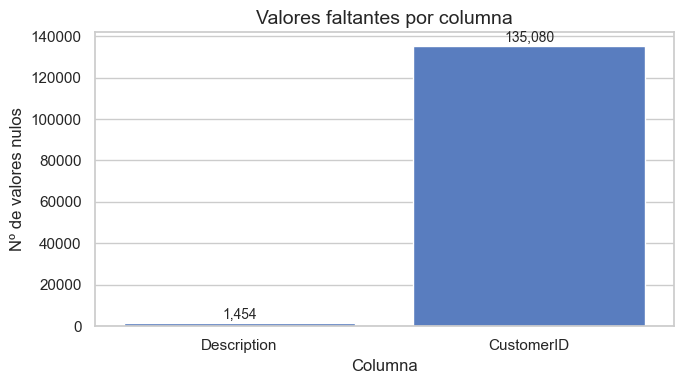

In [244]:
# 2.4.1 — Valores faltantes por columna
nulos_plot = df.isnull().sum()
nulos_plot = nulos_plot[nulos_plot > 0]

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=nulos_plot.index, y=nulos_plot.values, ax=ax)
ax.set_title('Valores faltantes por columna', fontsize=14)
ax.set_xlabel('Columna')
ax.set_ylabel('Nº de valores nulos')
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 500,
            f'{int(bar.get_height()):,}',
            ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.1_valores_faltantes.png', dpi=150)
plt.show()

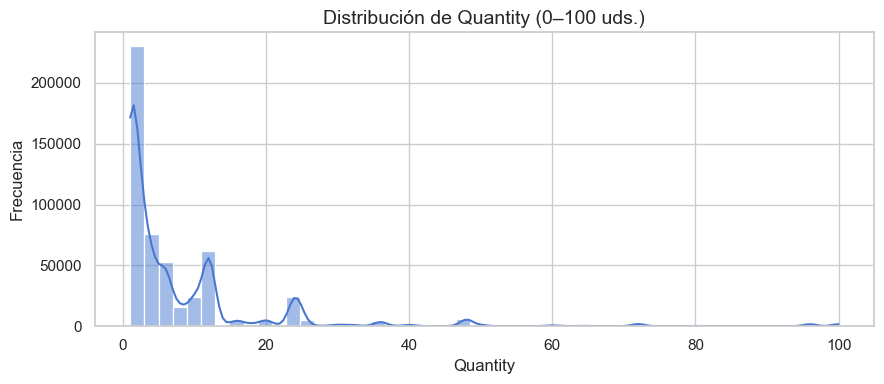

In [245]:
# 2.4.2 — Distribución de Quantity (rango normal: 0–100)
qty_filtrado = df[(df['Quantity'] > 0) & (df['Quantity'] <= 100)]

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(qty_filtrado['Quantity'], bins=50, ax=ax, kde=True)
ax.set_title('Distribución de Quantity (0–100 uds.)', fontsize=14)
ax.set_xlabel('Quantity')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.2_distribucion_quantity.png', dpi=150)
plt.show()

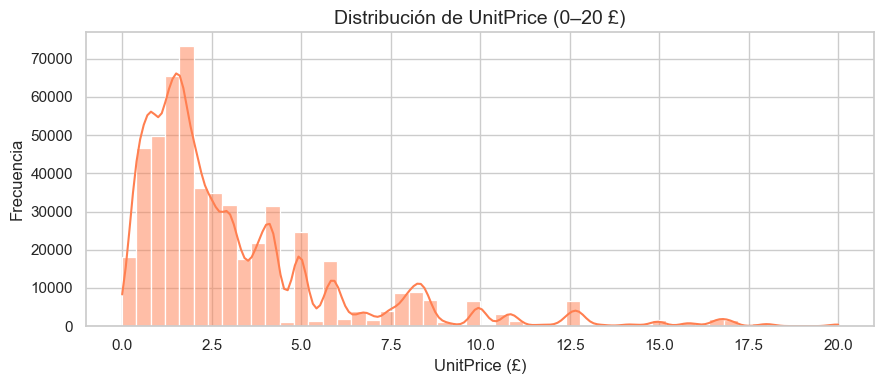

In [246]:
# 2.4.3 — Distribución de UnitPrice (rango normal: 0–20 £)
price_filtrado = df[(df['UnitPrice'] > 0) & (df['UnitPrice'] <= 20)]

fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(price_filtrado['UnitPrice'], bins=50, ax=ax, kde=True, color='coral')
ax.set_title('Distribución de UnitPrice (0–20 £)', fontsize=14)
ax.set_xlabel('UnitPrice (£)')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.3_distribucion_unitprice.png', dpi=150)
plt.show()

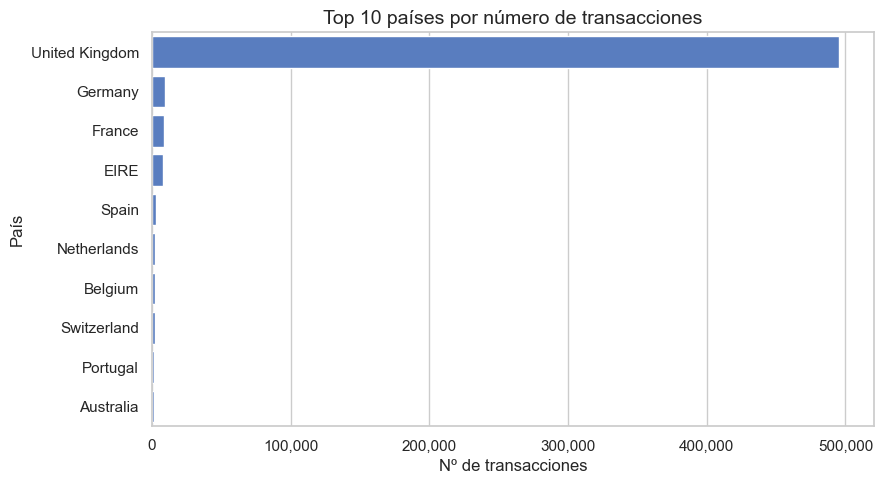

In [247]:
# 2.4.4 — Top 10 países por número de transacciones
top_paises = df['Country'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=top_paises.values, y=top_paises.index, ax=ax, orient='h')
ax.set_title('Top 10 países por número de transacciones', fontsize=14)
ax.set_xlabel('Nº de transacciones')
ax.set_ylabel('País')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.4_top10_paises.png', dpi=150)
plt.show()

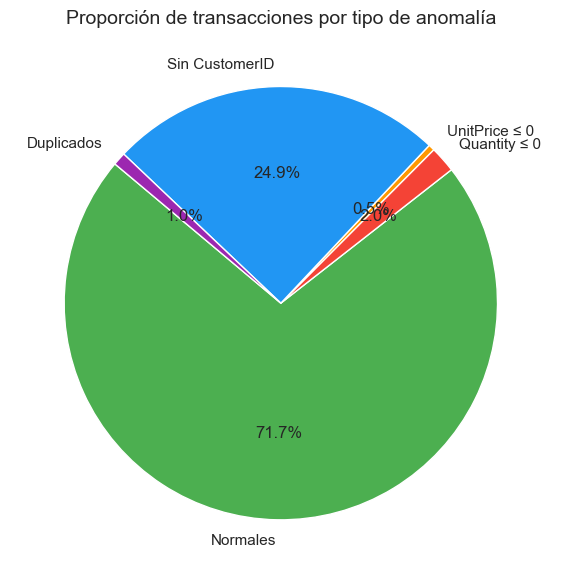

In [248]:
# 2.4.5 — Proporción de transacciones por tipo de anomalía
total        = len(df)
n_qty_neg    = (df['Quantity'] <= 0).sum()
n_price_neg  = (df['UnitPrice'] <= 0).sum()
n_sin_client = df['CustomerID'].isnull().sum()
n_duplicados = df.duplicated().sum()
n_normales   = total - n_qty_neg - n_price_neg - n_sin_client - n_duplicados

labels  = ['Normales', 'Quantity ≤ 0', 'UnitPrice ≤ 0', 'Sin CustomerID', 'Duplicados']
valores = [n_normales, n_qty_neg, n_price_neg, n_sin_client, n_duplicados]
colores = ['#4CAF50', '#F44336', '#FF9800', '#2196F3', '#9C27B0']

fig, ax = plt.subplots(figsize=(8, 6))
ax.pie(valores, labels=labels, colors=colores, autopct='%1.1f%%', startangle=140)
ax.set_title('Proporción de transacciones por tipo de anomalía', fontsize=14)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.5_proporcion_anomalias.png', dpi=150)
plt.show()

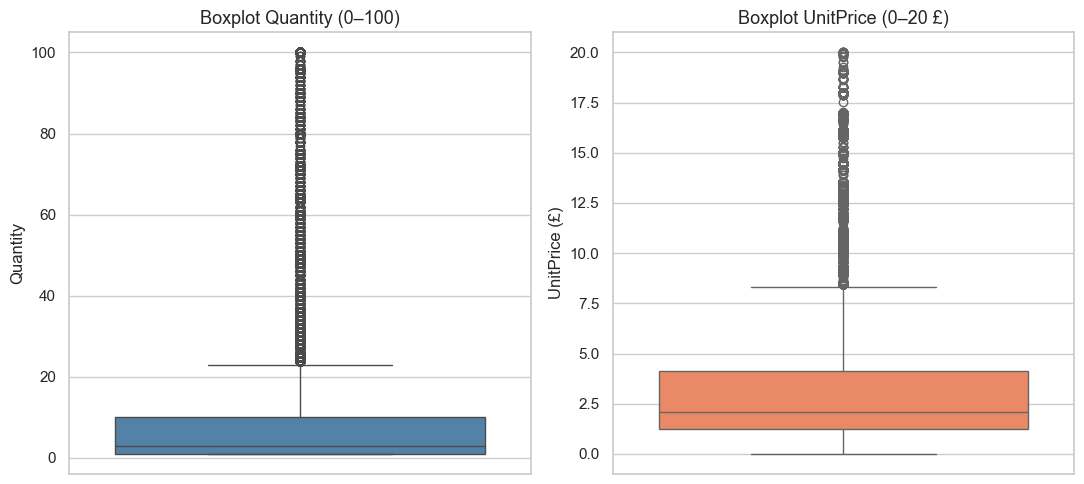

In [249]:
# 2.4.6 — Boxplots de Quantity y UnitPrice
qty_box   = df[(df['Quantity'] > 0)   & (df['Quantity'] <= 100)]['Quantity']
price_box = df[(df['UnitPrice'] > 0)  & (df['UnitPrice'] <= 20)]['UnitPrice']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
sns.boxplot(y=qty_box,   ax=axes[0], color='steelblue')
axes[0].set_title('Boxplot Quantity (0–100)', fontsize=13)
axes[0].set_ylabel('Quantity')

sns.boxplot(y=price_box, ax=axes[1], color='coral')
axes[1].set_title('Boxplot UnitPrice (0–20 £)', fontsize=13)
axes[1].set_ylabel('UnitPrice (£)')

plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.4.6_boxplots.png', dpi=150)
plt.show()

### 2.5 Análisis temporal

Convertimos `InvoiceDate` a tipo `datetime` y analizamos la distribución de transacciones a lo largo del tiempo: por día, por mes y por día de la semana. También identificamos los **días sin datos** en el rango analizado.

In [250]:
print('--- 2.5.1 Conversión de InvoiceDate a datetime ---')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'], format='mixed')
print(f'  Tipo resultante : {df["InvoiceDate"].dtype}')
print(f'  Fecha mínima    : {df["InvoiceDate"].min()}')
print(f'  Fecha máxima    : {df["InvoiceDate"].max()}')
print(f'  Rango total     : {(df["InvoiceDate"].max() - df["InvoiceDate"].min()).days} días')

# Columna de fecha normalizada (sin hora)
df['Fecha']     = df['InvoiceDate'].dt.normalize()
df['Mes']       = df['InvoiceDate'].dt.to_period('M')
df['DiaSemana'] = df['InvoiceDate'].dt.day_name()

--- 2.5.1 Conversión de InvoiceDate a datetime ---
  Tipo resultante : datetime64[us]
  Fecha mínima    : 2010-12-01 08:26:00
  Fecha máxima    : 2011-12-09 12:50:00
  Rango total     : 373 días


In [251]:
print('--- 2.5.2 Transacciones por día ---')
trans_por_dia = df.groupby('Fecha').size().rename('NumTransacciones')
print(f'  Días con datos     : {len(trans_por_dia)}')
print(f'  Media trans/día    : {trans_por_dia.mean():.1f}')
print(f'  Máximo trans/día   : {trans_por_dia.max():,} ({trans_por_dia.idxmax().date()})')
print(f'  Mínimo trans/día   : {trans_por_dia.min():,} ({trans_por_dia.idxmin().date()})')

print('\n--- 2.5.3 Días sin datos en el rango ---')
rango_completo = pd.date_range(start=df['Fecha'].min(), end=df['Fecha'].max(), freq='D')
dias_sin_datos = rango_completo.difference(trans_por_dia.index)
print(f'  Días totales en el rango : {len(rango_completo)}')
print(f'  Días con datos           : {len(trans_por_dia)}')
print(f'  Días sin datos           : {len(dias_sin_datos)}')
print(dias_sin_datos.strftime('%Y-%m-%d').tolist())

--- 2.5.2 Transacciones por día ---
  Días con datos     : 305
  Media trans/día    : 1776.8
  Máximo trans/día   : 5,331 (2011-12-05)
  Mínimo trans/día   : 279 (2011-02-06)

--- 2.5.3 Días sin datos en el rango ---
  Días totales en el rango : 374
  Días con datos           : 305
  Días sin datos           : 69
['2010-12-04', '2010-12-11', '2010-12-18', '2010-12-24', '2010-12-25', '2010-12-26', '2010-12-27', '2010-12-28', '2010-12-29', '2010-12-30', '2010-12-31', '2011-01-01', '2011-01-02', '2011-01-03', '2011-01-08', '2011-01-15', '2011-01-22', '2011-01-29', '2011-02-05', '2011-02-12', '2011-02-19', '2011-02-26', '2011-03-05', '2011-03-12', '2011-03-19', '2011-03-26', '2011-04-02', '2011-04-09', '2011-04-16', '2011-04-22', '2011-04-23', '2011-04-24', '2011-04-25', '2011-04-29', '2011-04-30', '2011-05-02', '2011-05-07', '2011-05-14', '2011-05-21', '2011-05-28', '2011-05-30', '2011-06-04', '2011-06-11', '2011-06-18', '2011-06-25', '2011-07-02', '2011-07-09', '2011-07-16', '2011-07-23'

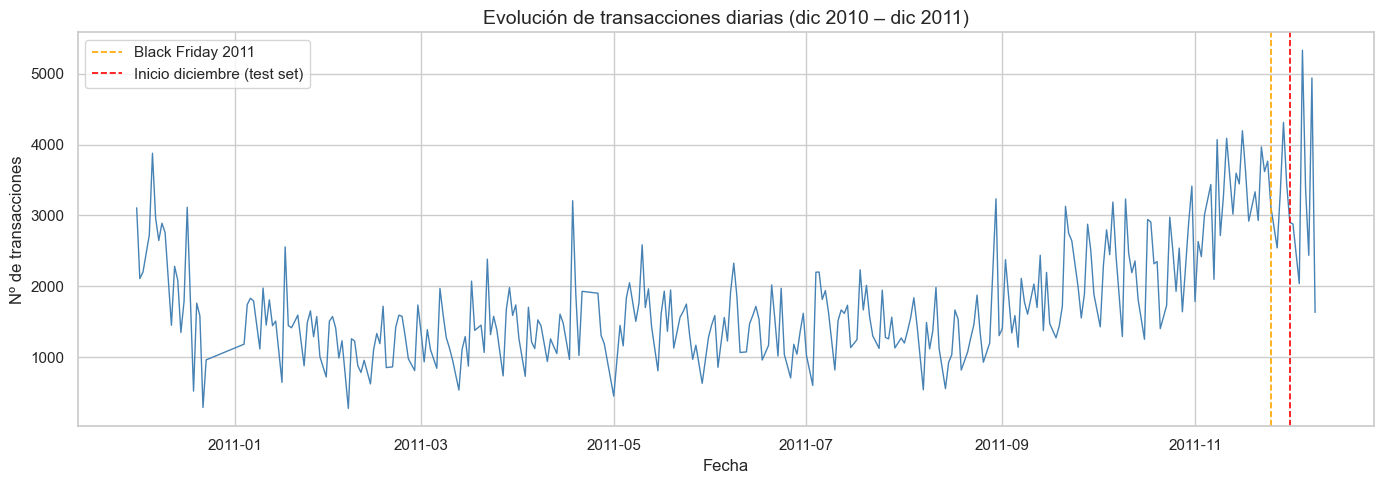

In [252]:
# 2.5.4 — Evolución de transacciones diarias
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(trans_por_dia.index, trans_por_dia.values, linewidth=1, color='steelblue')
ax.set_title('Evolución de transacciones diarias (dic 2010 – dic 2011)', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Nº de transacciones')
ax.axvline(pd.Timestamp('2011-11-25'), color='orange', linestyle='--', linewidth=1.2, label='Black Friday 2011')
ax.axvline(pd.Timestamp('2011-12-01'), color='red',    linestyle='--', linewidth=1.2, label='Inicio diciembre (test set)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.5.4_transacciones_diarias.png', dpi=150)
plt.show()

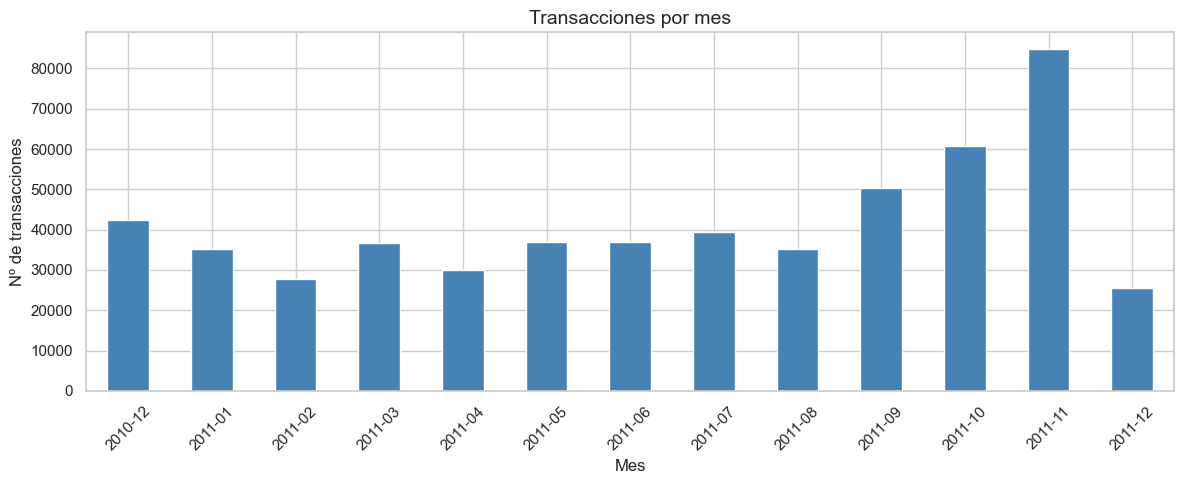

In [253]:
# 2.5.5 — Transacciones por mes
trans_por_mes = df.groupby('Mes').size().rename('NumTransacciones')

fig, ax = plt.subplots(figsize=(12, 5))
trans_por_mes.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Transacciones por mes', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Nº de transacciones')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.5.5_transacciones_por_mes.png', dpi=150)
plt.show()

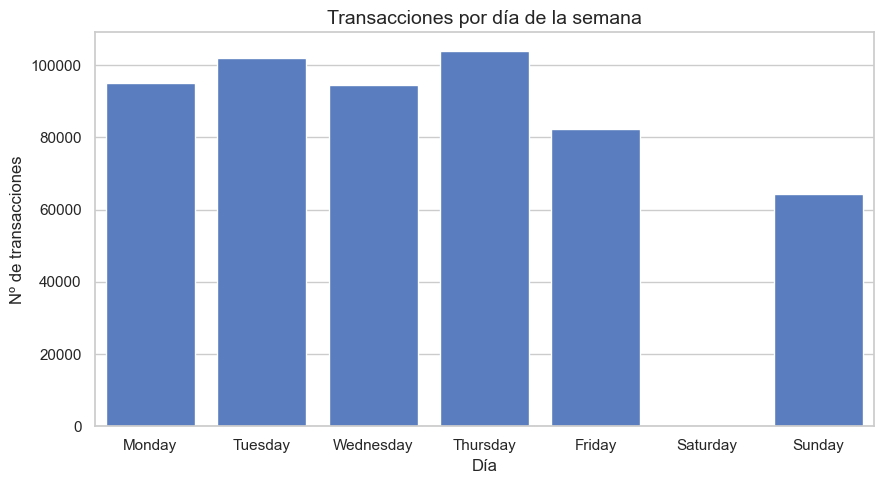

In [254]:
# 2.5.6 — Transacciones por día de la semana
dias_semana = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
trans_por_dia_semana = df.groupby('DiaSemana').size().reindex(dias_semana).rename('NumTransacciones')

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(x=trans_por_dia_semana.index, y=trans_por_dia_semana.values, ax=ax)
ax.set_title('Transacciones por día de la semana', fontsize=14)
ax.set_xlabel('Día')
ax.set_ylabel('Nº de transacciones')
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.5.6_transacciones_dia_semana.png', dpi=150)
plt.show()

### 2.6 Análisis de cancelaciones

Las facturas que empiezan por **`C`** en `InvoiceNo` son cancelaciones. Analizamos cuántas hay, cómo se cruzan con `Quantity < 0` y cuál es su evolución mensual.

Distinguimos tres categorías:
- **Cancelaciones normales**: prefijo `C` + `Quantity < 0`.
- **Cancelaciones con qty positiva**: prefijo `C` + `Quantity >= 0` (anomalía menor).
- **Huérfanos**: sin prefijo `C` pero con `Quantity < 0` (ajustes contables u otro tipo).

In [255]:
print('--- 2.6.1 Facturas con prefijo C ---')
df['EsCancelacion'] = df['InvoiceNo'].str.startswith('C')
n_cancelaciones = df['EsCancelacion'].sum()
print(f'  Total filas con prefijo C       : {n_cancelaciones:,}')
print(f'  % sobre total                   : {n_cancelaciones / len(df) * 100:.2f}%')
print(f'  Facturas únicas canceladas      : {df[df["EsCancelacion"]]["InvoiceNo"].nunique():,}')

--- 2.6.1 Facturas con prefijo C ---
  Total filas con prefijo C       : 9,288
  % sobre total                   : 1.71%
  Facturas únicas canceladas      : 3,836


In [256]:
print('--- 2.6.2 Cruce entre prefijo C y Quantity < 0 ---')
con_C_qty_neg = df[ df['EsCancelacion'] &  (df['Quantity'] < 0)]
con_C_qty_pos = df[ df['EsCancelacion'] & (df['Quantity'] >= 0)]
sin_C_qty_neg = df[~df['EsCancelacion'] &  (df['Quantity'] < 0)]
sin_C_qty_pos = df[~df['EsCancelacion'] & (df['Quantity'] >= 0)]

print(f'  Prefijo C + Qty<0  (cancelaciones normales)     : {len(con_C_qty_neg):>7,}')
print(f'  Prefijo C + Qty>=0 (cancelaciones qty positiva) : {len(con_C_qty_pos):>7,}')
print(f'  Sin C   + Qty<0    (huérfanos)                  : {len(sin_C_qty_neg):>7,}')
print(f'  Sin C   + Qty>=0   (transacciones normales)     : {len(sin_C_qty_pos):>7,}')

--- 2.6.2 Cruce entre prefijo C y Quantity < 0 ---
  Prefijo C + Qty<0  (cancelaciones normales)     :   9,288
  Prefijo C + Qty>=0 (cancelaciones qty positiva) :       0
  Sin C   + Qty<0    (huérfanos)                  :   1,336
  Sin C   + Qty>=0   (transacciones normales)     : 531,285


In [257]:
print('--- 2.6.3 Detalle de negativos huérfanos (sin prefijo C) ---')
print(f'  Total: {len(sin_C_qty_neg):,}')
if len(sin_C_qty_neg) > 0:
    display(sin_C_qty_neg[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice', 'CustomerID']].head(10))
    print('\n  StockCodes más frecuentes en huérfanos:')
    print(sin_C_qty_neg['StockCode'].value_counts().head(10))

print('\n--- 2.6.4 Cancelaciones con Quantity >= 0 (anomalía) ---')
print(f'  Total: {len(con_C_qty_pos):,}')
if len(con_C_qty_pos) > 0:
    display(con_C_qty_pos[['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'UnitPrice']].head(10))

--- 2.6.3 Detalle de negativos huérfanos (sin prefijo C) ---
  Total: 1,336


,InvoiceNo,StockCode,Description,Quantity,UnitPrice,CustomerID
2406,536589,21777,NaN,-10,0.0,NaN
4347,536764,84952C,NaN,-38,0.0,NaN
7188,536996,22712,NaN,-20,0.0,NaN
7189,536997,22028,NaN,-20,0.0,NaN
7190,536998,85067,NaN,-6,0.0,NaN
7192,537000,21414,NaN,-22,0.0,NaN
7193,537001,21653,NaN,-6,0.0,NaN
7195,537003,85126,NaN,-2,0.0,NaN
7196,537004,21814,NaN,-30,0.0,NaN
7197,537005,21692,NaN,-70,0.0,NaN



  StockCodes más frecuentes en huérfanos:
StockCode
85175     5
21830     5
85172     4
22719     4
82494L    4
72802C    4
21161     3
22162     3
22034     3
20966     3
Name: count, dtype: int64

--- 2.6.4 Cancelaciones con Quantity >= 0 (anomalía) ---
  Total: 0


In [258]:
print('--- 2.6.5 Cancelaciones por mes ---')
cancelaciones_mes = df[df['EsCancelacion']].groupby('Mes').size().rename('Cancelaciones')
total_mes         = df.groupby('Mes').size().rename('Total')
ratio_cancelacion = (cancelaciones_mes / total_mes * 100).round(2).rename('% Cancelaciones')
display(pd.concat([total_mes, cancelaciones_mes, ratio_cancelacion], axis=1))

--- 2.6.5 Cancelaciones por mes ---


,Total,Cancelaciones,% Cancelaciones
Mes,,,
2010-12,42481,728,1.71
2011-01,35147,701,1.99
2011-02,27707,475,1.71
2011-03,36748,699,1.90
2011-04,29916,559,1.87
2011-05,37030,621,1.68
2011-06,36874,711,1.93
2011-07,39518,685,1.73
2011-08,35284,668,1.89


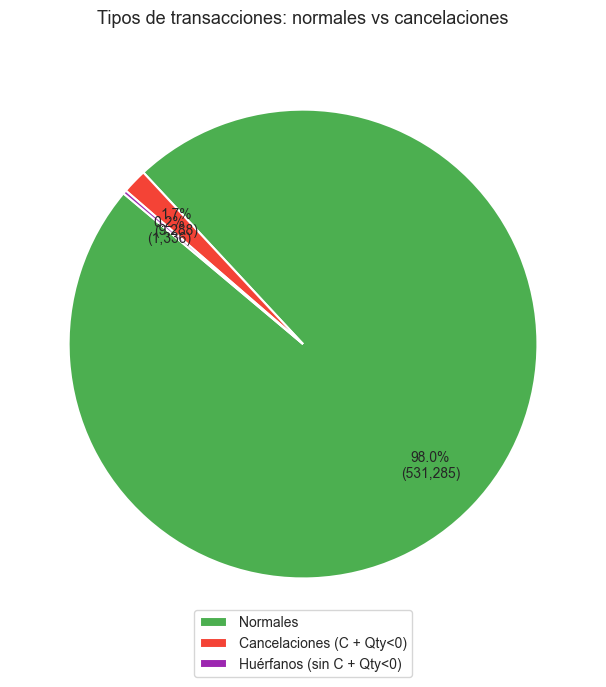

In [259]:
# 2.6.6 — Proporción cancelaciones vs normales
datos_grafico = {
    'Normales':                  len(sin_C_qty_pos),
    'Cancelaciones (C + Qty<0)': len(con_C_qty_neg),
    'Huérfanos (sin C + Qty<0)': len(sin_C_qty_neg),
}
labels_c  = list(datos_grafico.keys())
valores_c = list(datos_grafico.values())
colores_c = ['#4CAF50', '#F44336', '#9C27B0']

fig, ax = plt.subplots(figsize=(9, 7))
wedges, texts, autotexts = ax.pie(
    valores_c,
    colors=colores_c,
    autopct=lambda p: f'{p:.1f}%\n({int(p * sum(valores_c) / 100):,})',
    startangle=140,
    pctdistance=0.75,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for autotext in autotexts:
    autotext.set_fontsize(10)
ax.legend(wedges, labels_c, loc='lower center', bbox_to_anchor=(0.5, -0.08), ncol=1, fontsize=10)
ax.set_title('Tipos de transacciones: normales vs cancelaciones', fontsize=13, pad=20)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.6.6_cancelaciones_proporcion.png', dpi=150)
plt.show()

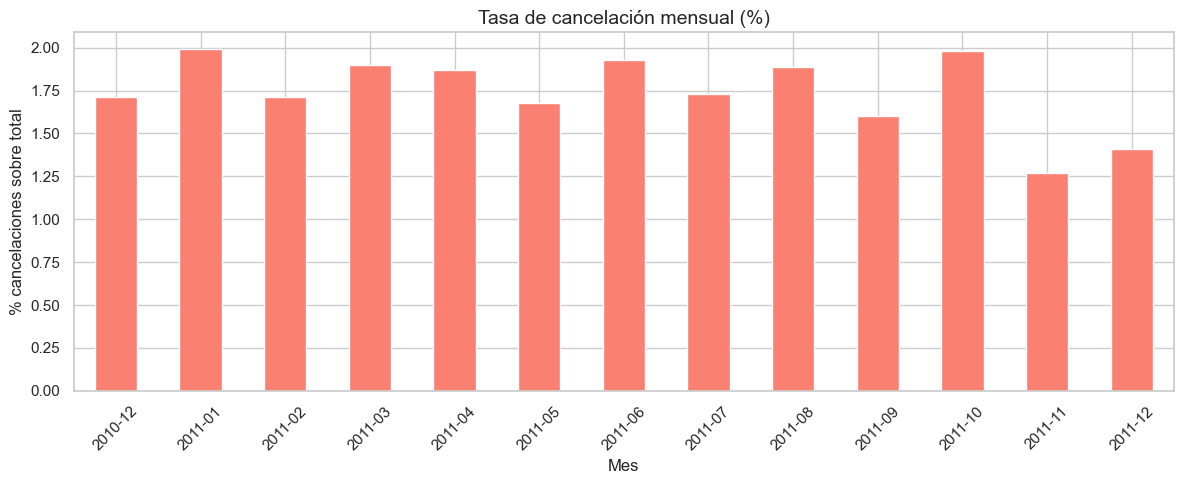

In [260]:
# 2.6.7 — Tasa de cancelación por mes
fig, ax = plt.subplots(figsize=(12, 5))
ratio_cancelacion.plot(kind='bar', ax=ax, color='salmon', edgecolor='white')
ax.set_title('Tasa de cancelación mensual (%)', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('% cancelaciones sobre total')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.6.7_tasa_cancelacion_mensual.png', dpi=150)
plt.show()

### 2.7 Ventas diarias brutas — Variable objetivo

Calculamos `TotalPrice = Quantity × UnitPrice` para obtener el valor económico de cada línea de transacción. Luego **agregamos por día** para tener una primera versión (sin limpiar) de la variable objetivo: **ventas totales diarias en £**.

> Nota: esta agregación es bruta, incluye cancelaciones y valores negativos. La versión limpia se generará en la siguiente sección.

In [261]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print('--- 2.7.1 Estadísticas de TotalPrice por fila ---')
print(df['TotalPrice'].describe())

--- 2.7.1 Estadísticas de TotalPrice por fila ---
count    541909.000000
mean         17.987795
std         378.810824
min     -168469.600000
25%           3.400000
50%           9.750000
75%          17.400000
max      168469.600000
Name: TotalPrice, dtype: float64


In [262]:
print('--- 2.7.2 Agregación de ventas por día (bruto) ---')
ventas_diarias = df.groupby('Fecha')['TotalPrice'].sum().rename('VentasDiarias')
print(f'  Días con datos            : {len(ventas_diarias)}')
print(f'  Venta media diaria        : £{ventas_diarias.mean():>12,.2f}')
print(f'  Venta mediana diaria      : £{ventas_diarias.median():>11,.2f}')
print(f'  Venta máxima diaria       : £{ventas_diarias.max():>11,.2f} ({ventas_diarias.idxmax().date()})')
print(f'  Venta mínima diaria       : £{ventas_diarias.min():>11,.2f} ({ventas_diarias.idxmin().date()})')
print(f'  Días con ventas negativas : {(ventas_diarias < 0).sum()}')

--- 2.7.2 Agregación de ventas por día (bruto) ---
  Días con datos            : 305
  Venta media diaria        : £   31,959.83
  Venta mediana diaria      : £  27,978.41
  Venta máxima diaria       : £ 112,141.11 (2011-11-14)
  Venta mínima diaria       : £  -1,566.23 (2011-01-05)
  Días con ventas negativas : 1


In [263]:
print('--- 2.7.3 Ventas totales por mes ---')
ventas_mes = df.groupby('Mes')['TotalPrice'].sum().rename('VentasMes')
print(ventas_mes.apply(lambda x: f'£{x:,.2f}'))

print('\n--- 2.7.4 Distribución de ventas diarias por percentiles ---')
percentiles_v = [0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
print(ventas_diarias.quantile(percentiles_v).apply(lambda x: f'£{x:,.2f}'))

--- 2.7.3 Ventas totales por mes ---
Mes
2010-12      £748,957.02
2011-01      £560,000.26
2011-02      £498,062.65
2011-03      £683,267.08
2011-04      £493,207.12
2011-05      £723,333.51
2011-06      £691,123.12
2011-07      £681,300.11
2011-08      £682,680.51
2011-09    £1,019,687.62
2011-10    £1,070,704.67
2011-11    £1,461,756.25
2011-12      £433,668.01
Freq: M, Name: VentasMes, dtype: str

--- 2.7.4 Distribución de ventas diarias por percentiles ---
0.01     £5,165.59
0.05     £7,737.82
0.10    £12,374.99
0.25    £20,728.14
0.50    £27,978.41
0.75    £42,912.40
0.90    £56,905.16
0.95    £62,918.36
0.99    £78,351.25
Name: VentasDiarias, dtype: str


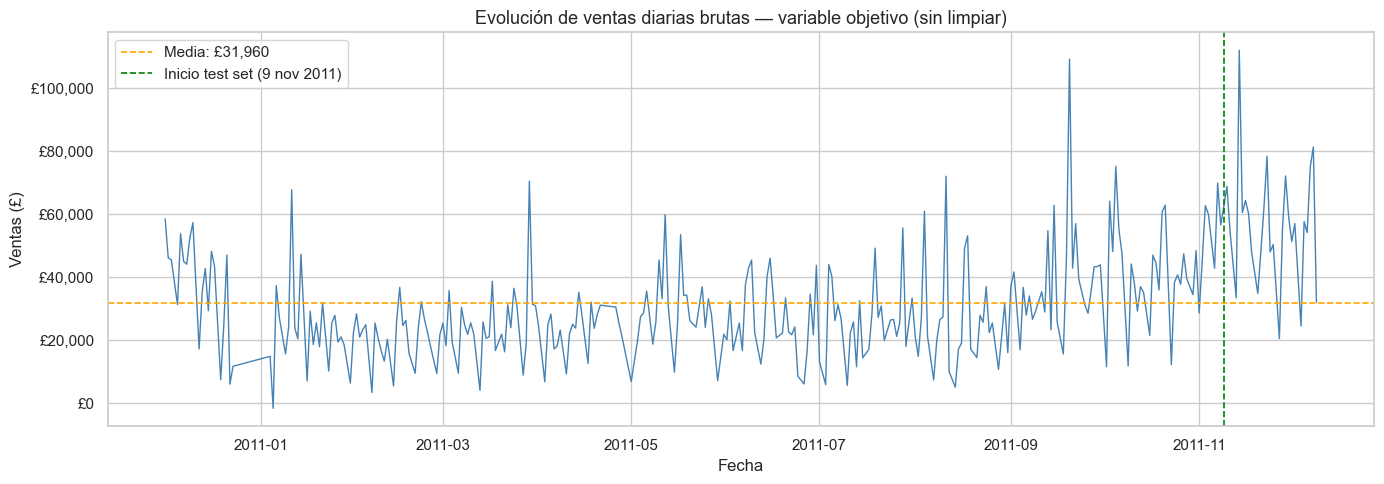

In [264]:
# 2.7.5 — Evolución de ventas diarias brutas
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ventas_diarias.index, ventas_diarias.values, linewidth=1, color='steelblue')
ax.axhline(ventas_diarias.mean(), color='orange', linestyle='--', linewidth=1.2,
           label=f'Media: £{ventas_diarias.mean():,.0f}')
ax.axvline(pd.Timestamp('2011-11-09'), color='green', linestyle='--', linewidth=1.2,
           label='Inicio test set (9 nov 2011)')
ax.set_title('Evolución de ventas diarias brutas — variable objetivo (sin limpiar)', fontsize=13)
ax.set_xlabel('Fecha')
ax.set_ylabel('Ventas (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.7.5_ventas_diarias_brutas.png', dpi=150)
plt.show()

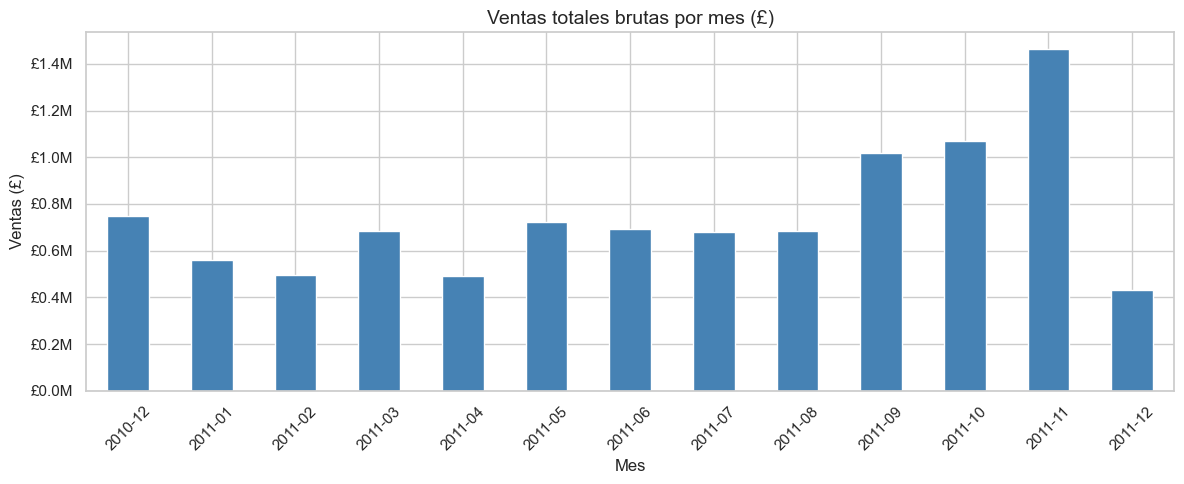

In [265]:
# 2.7.6 — Ventas totales por mes
fig, ax = plt.subplots(figsize=(12, 5))
ventas_mes.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Ventas totales brutas por mes (£)', fontsize=14)
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas (£)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x/1e6:.1f}M'))
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.7.6_ventas_mensuales_brutas.png', dpi=150)
plt.show()

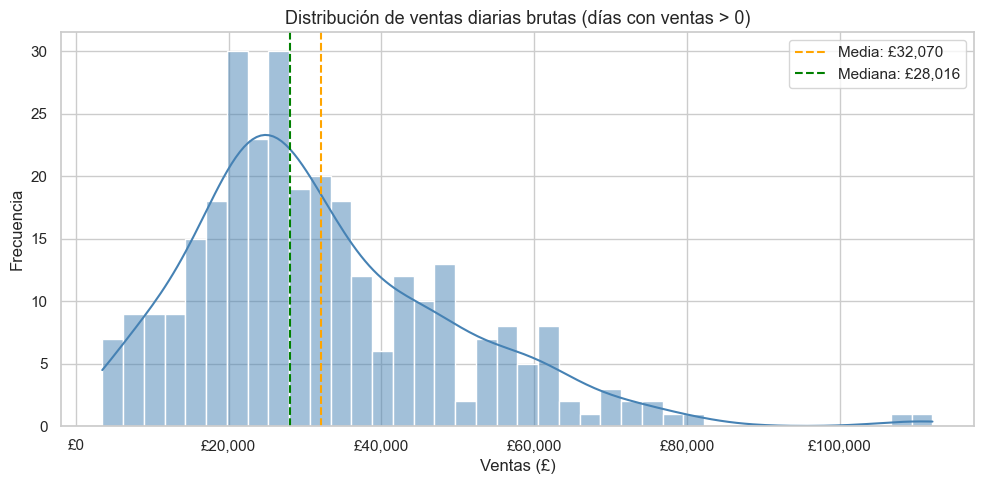

In [266]:
# 2.7.7 — Distribución de ventas diarias (días > 0)
ventas_positivas = ventas_diarias[ventas_diarias > 0]

fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(ventas_positivas, bins=40, ax=ax, kde=True, color='steelblue')
ax.axvline(ventas_positivas.mean(),   color='orange', linestyle='--', linewidth=1.5,
           label=f'Media: £{ventas_positivas.mean():,.0f}')
ax.axvline(ventas_positivas.median(), color='green',  linestyle='--', linewidth=1.5,
           label=f'Mediana: £{ventas_positivas.median():,.0f}')
ax.set_title('Distribución de ventas diarias brutas (días con ventas > 0)', fontsize=13)
ax.set_xlabel('Ventas (£)')
ax.set_ylabel('Frecuencia')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.savefig(f'{RUTA_GRAFICOS}2.7.7_distribucion_ventas_diarias.png', dpi=150)
plt.show()

### 2.8 Top clientes y top productos

Analizamos qué clientes y productos concentran la mayor parte de las ventas. Es relevante para detectar posibles outliers de negocio (un cliente mayorista con miles de unidades puede distorsionar los patrones de ventas minoristas).

In [267]:
print('--- 2.8.1 Top 10 clientes por volumen de ventas ---')
ventas_cliente = (
    df[df['CustomerID'].notna()]
    .groupby('CustomerID')['TotalPrice']
    .sum()
    .sort_values(ascending=False)
)
top10_clientes = ventas_cliente.head(10)
total_ventas   = df['TotalPrice'].sum()

print(f'  Ventas totales brutas: £{total_ventas:,.2f}')
print(f'\n  {"CustomerID":<15} {"Ventas (£)":>15} {"% sobre total":>15}')
print(f'  {"-"*45}')
for cid, ventas in top10_clientes.items():
    print(f'  {int(cid):<15} £{ventas:>13,.2f} {ventas / total_ventas * 100:>14.2f}%')

pct_top10 = top10_clientes.sum() / total_ventas * 100
print(f'\n  Top 10 clientes concentran el {pct_top10:.1f}% de las ventas totales')

--- 2.8.1 Top 10 clientes por volumen de ventas ---
  Ventas totales brutas: £9,747,747.93

  CustomerID           Ventas (£)   % sobre total
  ---------------------------------------------
  14646           £   279,489.02           2.87%
  18102           £   256,438.49           2.63%
  17450           £   187,482.17           1.92%
  14911           £   132,572.62           1.36%
  12415           £   123,725.45           1.27%
  14156           £   113,384.14           1.16%
  17511           £    88,125.38           0.90%
  16684           £    65,892.08           0.68%
  13694           £    62,653.10           0.64%
  15311           £    59,419.34           0.61%

  Top 10 clientes concentran el 14.0% de las ventas totales


# 3. LIMPIEZA DE DATOS

In [268]:
df_clean = df.copy()
filas_iniciales = len(df_clean)
print(f"\n\n{'='*60}")
print(f"  INICIO LIMPIEZA — Filas iniciales: {filas_iniciales:,}")
print(f"{'='*60}")



  INICIO LIMPIEZA — Filas iniciales: 541,909


### 3.1 ELIMINAR FILAS CON Description NULA

Motivo: el 100% de estas filas cumplen simultáneamente:
 - Description = NaN  → no sabemos qué producto es
 - UnitPrice = 0      → no generan ningún ingreso (TotalPrice = 0)
 - CustomerID = NaN   → no tienen cliente asociado
No son recuperables y solo añadirían ruido al modelo.

In [269]:
print("\n--- 3.1 Eliminar filas con Description nula ---")

antes = len(df_clean)
df_clean = df_clean.dropna(subset=['Description']).reset_index(drop=True)
eliminadas = antes - len(df_clean)

print(f"  Filas antes:     {antes:,}")
print(f"  Filas eliminadas: {eliminadas:,}")
print(f"  Filas después:   {len(df_clean):,}")
print(f"  Verificación — Description nulos restantes: {df_clean['Description'].isnull().sum()}")


--- 3.1 Eliminar filas con Description nula ---
  Filas antes:     541,909
  Filas eliminadas: 1,454
  Filas después:   540,455
  Verificación — Description nulos restantes: 0


### 3.2 ELIMINAR DUPLICADOS EXACTOS

 Una fila duplicada exacta tiene TODOS sus campos idénticos: mismo InvoiceNo,
 StockCode, Description, Quantity, UnitPrice, InvoiceDate, CustomerID y Country.
 Esto es físicamente imposible en un sistema transaccional real: si el mismo cliente
 compra el mismo producto en el mismo instante, el sistema generaría un InvoiceNo
 distinto o un timestamp diferente. Su presencia indica errores de doble inserción
 en la BBDD, exports corruptos o fallos de ETL.

In [270]:
print("\n--- 3.2 Eliminar duplicados exactos ---")

antes = len(df_clean)
df_clean = df_clean.drop_duplicates(keep='first', ignore_index=True)
eliminadas = antes - len(df_clean)

print(f"  Filas antes:      {antes:,}")
print(f"  Filas eliminadas: {eliminadas:,}")
print(f"  Filas después:    {len(df_clean):,}")
print(f"  Verificación — duplicados restantes: {df_clean.duplicated().sum()}")


--- 3.2 Eliminar duplicados exactos ---
  Filas antes:      540,455
  Filas eliminadas: 5,268
  Filas después:    535,187
  Verificación — duplicados restantes: 0



### 3.3 ELIMINAR NEGATIVOS HUÉRFANOS

 Son filas con Quantity < 0 pero SIN prefijo "C" en InvoiceNo.
 El análisis directo del CSV confirma que el 100% cumple simultáneamente:
   - UnitPrice = 0.0  → TotalPrice = 0 siempre, sin impacto en ingresos
   - CustomerID = NaN → ninguna tiene cliente asociado
   - InvoiceNo sin "C" → el sistema nunca las registró como cancelación 

In [271]:
print("\n--- 3.3 Eliminar negativos huérfanos (ajustes de almacén) ---")

antes = len(df_clean)
mask_huerfanos = (
    ~df_clean['InvoiceNo'].str.startswith('C', na=False) &
    (df_clean['Quantity'] < 0) &
    (df_clean['UnitPrice'] == 0.0)
)
df_clean = df_clean[~mask_huerfanos].reset_index(drop=True)
eliminadas = antes - len(df_clean)

print(f"  Filas antes:      {antes:,}")
print(f"  Filas eliminadas: {eliminadas:,}")
print(f"  Filas después:    {len(df_clean):,}")
print(f"  Verificación — negativos huérfanos restantes: {(~df_clean['InvoiceNo'].str.startswith('C', na=False) & (df_clean['Quantity'] < 0) & (df_clean['UnitPrice'] == 0.0)).sum()}")


--- 3.3 Eliminar negativos huérfanos (ajustes de almacén) ---
  Filas antes:      535,187
  Filas eliminadas: 474
  Filas después:    534,713
  Verificación — negativos huérfanos restantes: 0


### 3.4 ELIMINAR STOCKCODES NO ESTÁNDAR

In [272]:
print("\n--- 3.4 Eliminar StockCodes no estándar ---")

antes = len(df_clean)
mask_std = df_clean['StockCode'].str.match(r'^[0-9]{5}[A-Za-z]?$', na=False)
df_clean = df_clean[mask_std].reset_index(drop=True)
eliminadas = antes - len(df_clean)

print(f"  Filas antes:      {antes:,}")
print(f"  Filas eliminadas: {eliminadas:,}")
print(f"  Filas después:    {len(df_clean):,}")
n_no_std = (~df_clean['StockCode'].str.match(r'^[0-9]{5}[A-Za-z]?$', na=False)).sum()
print(f"  Verificación — StockCodes no estándar restantes: {n_no_std}")


--- 3.4 Eliminar StockCodes no estándar ---
  Filas antes:      534,713
  Filas eliminadas: 3,357
  Filas después:    531,356
  Verificación — StockCodes no estándar restantes: 0


### 3.5 CAPPING (WINSORIZACIÓN) DE OUTLIERS EN Quantity Y UnitPrice


In [273]:
print("\n--- 3.5 Capping de outliers (winsorización al percentil 99) ---")

cap_qty   = df_clean.loc[df_clean['Quantity']  > 0, 'Quantity'].quantile(0.99)
cap_price = df_clean.loc[df_clean['UnitPrice'] > 0, 'UnitPrice'].quantile(0.99)

print(f"  Umbral Quantity   (p99): {cap_qty:.1f} uds  →  clip [{-cap_qty:.1f}, {cap_qty:.1f}]")
print(f"  Umbral UnitPrice  (p99): £{cap_price:.2f}  →  clip [-, {cap_price:.2f}]")

n_qty_sup  = (df_clean['Quantity']  >  cap_qty).sum()
n_qty_inf  = (df_clean['Quantity']  < -cap_qty).sum()
n_price_sup = (df_clean['UnitPrice'] >  cap_price).sum()
print(f"  Filas Quantity  > +umbral (recortadas arriba): {n_qty_sup:,}")
print(f"  Filas Quantity  < -umbral (recortadas abajo):  {n_qty_inf:,}")
print(f"  Filas UnitPrice > umbral  (recortadas arriba): {n_price_sup:,}")

df_clean['Quantity']  = df_clean['Quantity'].clip(lower=-cap_qty, upper=cap_qty)
df_clean['UnitPrice'] = df_clean['UnitPrice'].clip(upper=cap_price)

# Recalcular TotalPrice con los valores ya capeados
df_clean['TotalPrice'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f"  Quantity  rango tras capping:  [{df_clean['Quantity'].min():.1f}, {df_clean['Quantity'].max():.1f}]")
print(f"  UnitPrice máxima tras capping: £{df_clean['UnitPrice'].max():.2f}")
print(f"  Filas totales (sin cambio):    {len(df_clean):,}")


--- 3.5 Capping de outliers (winsorización al percentil 99) ---
  Umbral Quantity   (p99): 100.0 uds  →  clip [-100.0, 100.0]
  Umbral UnitPrice  (p99): £16.63  →  clip [-, 16.63]
  Filas Quantity  > +umbral (recortadas arriba): 4,883
  Filas Quantity  < -umbral (recortadas abajo):  154
  Filas UnitPrice > umbral  (recortadas arriba): 4,889
  Quantity  rango tras capping:  [-100.0, 100.0]
  UnitPrice máxima tras capping: £16.63
  Filas totales (sin cambio):    531,356


### 3.6 CONSERVAR FILAS CON CustomerID NULO

In [ ]:
print("\n--- 3.6 CustomerID nulo — decisión: conservar ---")

n_sin_cliente = df_clean['CustomerID'].isnull().sum()
pct = n_sin_cliente / len(df_clean) * 100
print(f"  Filas con CustomerID nulo: {n_sin_cliente:,} ({pct:.2f}%)")
print(f"  Decisión: se conservan — son ventas anónimas válidas para la variable objetivo")
print(f"  Filas totales sin cambio:  {len(df_clean):,}")

---
## Resumen del EDA

| Hallazgo | Valor |
|---------|-------|
| Filas totales | ~541.909 |
| Columnas | 8 |
| Filas con `CustomerID` nulo | ~135.080 (24,9 %) |
| Filas con `Description` nula | ~1.454 (0,27 %) |
| Filas duplicadas exactas | ~5.268 (0,97 %) |
| Transacciones con `Quantity <= 0` | ~10.624 (1,96 %) |
| Transacciones con `UnitPrice <= 0` | ~2.515 (0,46 %) |
| StockCodes no estándar | ~33.000 aprox. |
| Días sin datos en el rango | fines de semana y festivos |

**Próximo paso → Sección 3: Limpieza de datos**